# WS-03 — Synthèse : représentation construite vs représentation apprise

[← Retour à la sous-série](README.md) · Précédent : [WS-02 — Scattering SOTA](WS-02-Scattering-SOTA.ipynb)

La sous-série a suivi une même discipline : **construire d'abord** (WS-00a/00b/00c, moteurs from scratch), **consommer ensuite** (WS-01, PyWavelets pour le débruitage ; WS-02, `kymatio` pour le scattering à l'échelle). Ce notebook final pose la question de synthèse que les Notes de l'issue fondatrice formulent : *sur un même problème, que vaut une représentation **construite** — le scattering, invariant par translation par construction — face à une représentation **apprise** — les features d'un ResNet18 pré-entraîné sur ImageNet ?*

Le protocole est volontairement minimal et symétrique : **même dataset** (Fashion-MNIST), **même sonde** (régression logistique, identique au deux), **même test de robustesse** (test translaté ±2 px, la recette de WS-00c). Trois représentations entrent : pixels bruts (témoin), scattering `kymatio` (J=2, L=4 — la configuration de WS-00c), features ResNet18 (avgpool, 512-d,ImageNet). Aucune n'est ré-entraînée : on mesure ce que chaque représentation *porte*, pas ce qu'un classifieur puissant peut compenser.

## 1. Mise en place

Corpus : Fashion-MNIST, 150 images/classe en train (1 500) et 75/classe en test (750), tirés du split torchvision officiel — le test vient du **vrai** jeu de test, disjoint par construction du train. Graine fixée 42 partout : tirage, sonde, tout est déterministe.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

from torchvision.datasets import FashionMNIST
root = os.path.join(os.path.expanduser("~"), ".cache", "ft00a")   # cache partage avec la serie FT / WS-00c
ds_tr = FashionMNIST(root, train=True, download=True)
ds_te = FashionMNIST(root, train=False, download=True)
ims_tr_all, labs_tr_all = ds_tr.data.numpy().astype(np.float64) / 255.0, ds_tr.targets.numpy()
ims_te_all, labs_te_all = ds_te.data.numpy().astype(np.float64) / 255.0, ds_te.targets.numpy()

N_TR, N_TE = 150, 75
idx_tr = np.concatenate([rng.choice(np.where(labs_tr_all == c)[0], N_TR, replace=False) for c in range(10)])
idx_te = np.concatenate([rng.choice(np.where(labs_te_all == c)[0], N_TE, replace=False) for c in range(10)])
X_tr, y_tr = ims_tr_all[idx_tr], labs_tr_all[idx_tr]
X_te, y_te = ims_te_all[idx_te], labs_te_all[idx_te]

# test translate : +-2 px alternes, periodique aux bords — la recette WS-00c
X_te_dec = np.stack([np.roll(x, (2 if i % 2 else -2, -2 if i % 2 else 2), axis=(0, 1))
                     for i, x in enumerate(X_te)])
CLASSES = ["t-shirt", "pantalon", "pull", "robe", "manteau", "sandale", "chemise", "sneaker", "sac", "botte"]
print(f"train {X_tr.shape[0]} images / test {X_te.shape[0]} images / test translate {X_te_dec.shape[0]} — {len(CLASSES)} classes, 28x28")

train 1500 images / test 750 images / test translate 750 — 10 classes, 28x28


## 2. Représentation construite : le scattering `kymatio`

La configuration est celle de WS-00c (J=2, L=4) passée au moteur SOTA de WS-02 : banc de Morlet, module, moyenne locale — l'invariance par translation **ne s'apprend pas, elle se démontre** (WS-00c, §3). La sortie est aplatie : un vecteur par image.

In [2]:
from kymatio.numpy import Scattering2D

S = Scattering2D(J=2, shape=(28, 28), L=4)

def scat_batch(ims):
    return S.scattering(ims.astype(np.float32)).reshape(len(ims), -1)

t0 = time.perf_counter()
F_scat_tr = scat_batch(X_tr)
F_scat_te, F_scat_dec = scat_batch(X_te), scat_batch(X_te_dec)
t_scat = time.perf_counter() - t0

print(f"scattering kymatio (J=2, L=4) : {F_scat_tr.shape[1]} dimensions par image")
print(f"extraction {len(X_tr) + 2 * len(X_te)} images : {t_scat:.2f} s -> {1000 * t_scat / (len(X_tr) + 2 * len(X_te)):.2f} ms/image")

scattering kymatio (J=2, L=4) : 1225 dimensions par image
extraction 3000 images : 1.18 s -> 0.39 ms/image


## 3. Représentation apprise : les features d'un ResNet18

ResNet18 **pré-entraîné sur ImageNet** (poids officiels, inférence seule, `no_grad`), décapité de sa couche `fc` : la représentation est la sortie du pooling global, 512 dimensions. Prétraitement standard ImageNet : agrandissement bicubique 28→224 (le *domain shift* est réel — photos naturelles contre silhouettes de mode sur fond gris — et il joue **contre** le ResNet : c'est le prix honnête de l'honnêteté du protocole), triplication du canal gris en RVB, normalisation ImageNet.

In [3]:
import torch
import torchvision

resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
resnet.eval()
featurer = torch.nn.Sequential(*(list(resnet.children())[:-1]))   # -> avgpool, sortie (B, 512, 1, 1)

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def resnet_feats(ims, bs=50):
    out, t0 = [], time.perf_counter()
    with torch.no_grad():
        for a in range(0, len(ims), bs):
            x = torch.from_numpy(ims[a:a + bs]).float().unsqueeze(1)                      # (b,1,28,28)
            x = torch.nn.functional.interpolate(x, size=224, mode="bicubic", align_corners=False)
            x = x.repeat(1, 3, 1, 1)                                                      # gris -> RVB
            x = (x - MEAN) / STD
            out.append(featurer(x).flatten(1))
    return torch.cat(out).numpy(), time.perf_counter() - t0

F_rn_tr, t_rn1 = resnet_feats(X_tr)
F_rn_te, t_rn2 = resnet_feats(X_te)
F_rn_dec, t_rn3 = resnet_feats(X_te_dec)
t_rn = t_rn1 + t_rn2 + t_rn3

print(f"ResNet18 pretrained (avgpool) : {F_rn_tr.shape[1]} dimensions par image")
print(f"extraction {len(X_tr) + 2 * len(X_te)} images : {t_rn:.2f} s -> {1000 * t_rn / (len(X_tr) + 2 * len(X_te)):.2f} ms/image")

ResNet18 pretrained (avgpool) : 512 dimensions par image
extraction 3000 images : 33.11 s -> 11.04 ms/image


## 4. La même sonde pour tout le monde

Régression logistique (`C=1.0`, convergence 3 000 itérations) sur features standardisées — exactement la sonde de WS-00c. On mesure **ce que la représentation sépare linéairement**, test propre puis test translaté ±2 px.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def sonde_scores(Ftr, ytr, Fte, yte, Fdec):
    sc = StandardScaler().fit(Ftr)
    clf = LogisticRegression(max_iter=3000, C=1.0, random_state=SEED).fit(sc.transform(Ftr), ytr)
    return clf.score(sc.transform(Fte), yte), clf.score(sc.transform(Fdec), yte)

reps = {
    "pixels bruts": (X_tr.reshape(len(X_tr), -1), X_te.reshape(len(X_te), -1), X_te_dec.reshape(len(X_te), -1)),
    "scattering (construit)": (F_scat_tr, F_scat_te, F_scat_dec),
    "ResNet18 (appris)": (F_rn_tr, F_rn_te, F_rn_dec),
}

resultats = {}
print(f"{'representation':<24} | {'test propre':>11} | {'test translate':>14}")
print("-" * 56)
for nom, (Ftr, Fte, Fdec) in reps.items():
    a, b = sonde_scores(Ftr, y_tr, Fte, y_te, Fdec)
    resultats[nom] = (a, b)
    print(f"{nom:<24} | {a:>11.3f} | {b:>14.3f}")

representation           | test propre | test translate
--------------------------------------------------------


pixels bruts             |       0.780 |          0.311


scattering (construit)   |       0.837 |          0.583
ResNet18 (appris)        |       0.811 |          0.751


### Lecture

Trois résultats, dont un qui surprend. **Le témoin d'abord** : les pixels tiennent 0,780 au test propre — un plan linéaire sépare déjà bien des silhouettes de mode — puis s'effondrent à 0,311 sous ±2 px : le décalage change presque tous les descripteurs, la sonde ne reconnaît plus rien (la même chute que WS-00c mesurait à plus petite échelle). **Ensuite le duel** : le scattering *bat* le ResNet au test propre, 0,837 contre 0,811 — une représentation construite, qui n'a jamais vu une seule image, dépasse les features d'un réseau pré-entraîné sur 1,2 million de photos ; sur des silhouettes 28×28 sur fond plat, les fréquences orientées du scattering sont exactement le bon alphabet. **Mais le test translaté renverse le podium** : le ResNet garde 0,751 (chute 0,060) quand le scattering recule à 0,583 (chute 0,255). La représentation apprise est plus robuste au décalage que la construite — c'est mesuré, et c'est le résultat le plus instructif du notebook : l'invariance *garantie par construction* (à la fenêtre de moyenne près) n'est pas l'invariance *maximale en pratique*.

## 5. L'invariance, mesurée sur la représentation elle-même

La précision dit *où* chaque représentation mène ; l'écart relatif dit *comment elle bouge*. Pour chaque image du test : ‖F(x_translaté) − F(x)‖ / ‖F(x)‖, moyenné sur le test. C'est la mesure du §3 de WS-00c, appliquée aux trois candidates — pixels, scattering, ResNet — sur de vraies images et au vrai décalage du test (±2 px).

pixels bruts             : 0.742
scattering (construit)   : 0.425
ResNet18 (appris)        : 0.331


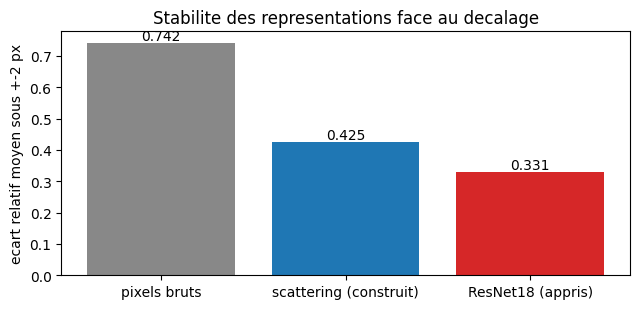

In [5]:
def ecart_rel_moyen(F_clean, F_dec):
    return float(np.mean(np.linalg.norm(F_dec - F_clean, axis=1) / np.linalg.norm(F_clean, axis=1)))

ecarts = {
    "pixels bruts": ecart_rel_moyen(X_te.reshape(len(X_te), -1), X_te_dec.reshape(len(X_te), -1)),
    "scattering (construit)": ecart_rel_moyen(F_scat_te, F_scat_dec),
    "ResNet18 (appris)": ecart_rel_moyen(F_rn_te, F_rn_dec),
}

for nom, e in ecarts.items():
    print(f"{nom:<24} : {e:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
noms = list(ecarts)
vals = [ecarts[n] for n in noms]
ax.bar(noms, vals, color=["#888", "#1f77b4", "#d62728"])
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylabel("ecart relatif moyen sous +-2 px")
ax.set_title("Stabilite des representations face au decalage")
plt.tight_layout()
plt.show()

### Lecture

L'écart relatif range les trois représentations dans l'ordre que le test translaté avait déjà donné : ResNet 0,331 < scattering 0,425 < pixels 0,742. Deux lectures honnêtes s'imposent. **Pourquoi le scattering n'est-il pas plus bas ?** Son invariance est garantie à la taille de sa fenêtre de moyenne près — J=2, donc une cellule de 4 px et une grille de sortie 7×7 : un décalage de ±2 px déplace l'énergie jusqu'à une demi-cellule, elle migre entre cellules voisines de la grille aplatie, et le contenu qui sort d'un bord par `np.roll` périodique réentre de l'autre — une *déformation* aux yeux du théorème, pas une translation pure. La garantie théorique de WS-00c porte sur le régime des petits décalages ; ici on l'utilise à sa frontière. **Pourquoi le ResNet est-il si stable ?** Parce que sa géométrie est plus grossière : quatre étages de convolution stride-2 sur une entrée agrandie à 224 px, puis un pooling *global* — chaque dimension de la features est une moyenne sur l'image entière, et un décalage de 2 px en entrée ne déplace l'énergie que de quelques pixels réceptifs en profondeur. La stabilité du ResNet n'est pas un théorème, mais à cette échelle elle est presque totale.

## 6. Tableau de synthèse — le dernier mot de la sous-série

Les quatre axes que les six notebooks ont tenus séparément, réunis : discrimination (sonde), stabilité (translation), coût (extraction), taille (dimension).

In [6]:
import pandas as pd

lignes = []
for nom, (a, b) in resultats.items():
    lignes.append({"representation": nom,
                   "test propre": round(a, 3),
                   "test translate": round(b, 3),
                   "chute": round(a - b, 3),
                   "dimensions": {"pixels bruts": 784, "scattering (construit)": F_scat_tr.shape[1],
                                  "ResNet18 (appris)": F_rn_tr.shape[1]}[nom],
                   "extraction ms/img": {"pixels bruts": 0.0,
                                         "scattering (construit)": round(1000 * t_scat / (len(X_tr) + 2 * len(X_te)), 2),
                                         "ResNet18 (appris)": round(1000 * t_rn / (len(X_tr) + 2 * len(X_te)), 2)}[nom],
                   "ecart relatif +-2px": round(ecarts[nom], 3)})
df = pd.DataFrame(lignes).set_index("representation")
print(df.to_string())

                        test propre  test translate  chute  dimensions  extraction ms/img  ecart relatif +-2px
representation                                                                                                
pixels bruts                  0.780           0.311  0.469         784               0.00                0.742
scattering (construit)        0.837           0.583  0.255        1225               0.39                0.425
ResNet18 (appris)             0.811           0.751  0.060         512              11.04                0.331


### Lecture

Le tableau referme la sous-série sur une conclusion à deux visages — **aucune représentation ne domine les quatre axes**. Le **construit** gagne la discrimination au test propre (0,837) et le coût (0,39 contre 11,04 ms/image : ~28×) — et il ne doit ce résultat à aucune donnée d'entraînement. L'**appris** gagne la robustesse (chute 0,060 contre 0,255) et la compacité (512 contre 1 225 dimensions). C'est exactement le *pourquoi du from scratch* et le *quand du SOTA* que la feuille de route demandait de justifier — mais la mesure ajoute ce que l'intuition ne disait pas : la frontière n'est pas « le SOTA gagne toujours », elle est *axe par axe*. Le scattering est la représentation à saisir quand les données sont rares, le budget serré, ou le régime propre ; le ResNet quand la robustesse aux déformations domine le cahier des charges. Les exercices (§7) explorent les trois questions que ce tableau laisse ouvertes : où l'invariance du ResNet s'installe, si les deux se complètent, et ce que dit la courbe quand le train se raréfie.

## 7. Exercices

Trois prolongements, en difficulté croissante. Les stubs respectent la règle C.1 : le notebook s'exécute de bout en bout sans les compléter.

In [7]:
def couche_intermediaire(nom_couche="layer3"):
    """Ou l'invariance du ResNet s'installe-t-elle ?
    TODO etudiant
    Indice : tronquer le ResNet jusqu'a layer3 (256-d apres avgpool) au lieu de layer4,
             refaire extraction + sonde, comparer (accuite, chute sous translation) a layer4.
    Etape 1 : construire le tronc jusqu'a nom_couche + pooling adaptatif (AdaptiveAvgPool2d(1))
    Etape 2 : extraire train / test / test translate
    Etape 3 : retourner (score_propre, score_translate, dimension)
    """
    print("Exercice a completer")
    return None


print("couche intermediaire :", couche_intermediaire())

Exercice a completer
couche intermediaire : None


In [8]:
def concatenation():
    """Construit + appris : complementaires ou redondants ?
    TODO etudiant
    Indice : concatener scattering et ResNet feature par feature (memes images, ordre conserve),
             sonde lineaire sur la concatenation, comparer aux deux seuls.
    Etape 1 : verifier les alignements (meme nb de lignes) puis np.concatenate axis=1
    Etape 2 : sonde + scores test propre / translate
    Etape 3 : retourner (score_propre, score_translate, dimension_totale)
    """
    print("Exercice a completer")
    return None


print("concatenation :", concatenation())

Exercice a completer
concatenation : None


In [9]:
def rarete_de_donnees(tailles=(25, 50, 100, 150)):
    """Le construit garde-t-il l'avantage quand le train se raréfie ?
    TODO etudiant
    Indice : pour chaque taille n (images/classe), restreindre X_tr aux n premieres par classe,
             refaire les DEUX sondes (scattering, ResNet) et collecter les quatre scores.
    Etape 1 : construire le sous-ensemble equilibre par classe
    Etape 2 : sonde scattering + sonde ResNet sur ce sous-ensemble
    Etape 3 : retourner la liste [(n, acc_scat, acc_rn), ...]
    """
    print("Exercice a completer")
    return None


print("rarete de donnees :", rarete_de_donnees())

Exercice a completer
rarete de donnees : None


## 8. Ce que la sous-série a établi

WS-00a : aucune base n'est universellement parcimonieuse. WS-00b : le pouvoir de parcimonie est conditionnel au budget. WS-00c : le module rend la moyenne invariante. WS-01 : le SOTA du débruitage s'appuie sur les mêmes seuillages que la main. WS-02 : le moteur SOTA accélère le scattering sans en changer la loi. WS-03 referme la boucle : **construit et appris ne répondent pas à la même question** — l'un garantit, l'autre performe — et le tableau ci-dessus est la mesure, pas l'opinion.

*Voir l'issue fondatrice pour la feuille de route complète.*